# Monte Carlo methods

They are a broad class of computational algorithms that rely on repeated random sampling to obtain numerical results.


The underlying concept is to use randomness to solve problems that might be deterministic in principle.


They are often used in physical and mathematical problems and are most useful when it is difficult or impossible to use other approaches.


Monte Carlo methods are mainly used in three problem classes:

- optimization

- numerical integration

- generating draws from a probability distribution.

## Applications in physics:

In physics-related problems, Monte Carlo methods are useful for simulating systems with many coupled degrees of freedom:

- Selection effects: We may not be able to see the whole sample (e.g. instrumental limitations). Think about supernovae and the standar candle.

- Fluids

- Disordered materials

- Strongly coupled solids

- Cellular structures

## Monte Carlo approach:

The (general) method consists of the following steps:

1. Define a domain of possible inputs.

2. Generate inputs randomly from a probability distribution over the domain.

3. Perform a deterministic computation on the inputs

4. Aggregate the results

### Formal steps from the IBM website:

https://www.ibm.com/topics/monte-carlo-simulation


1. Set up the predictive model, identifying both the dependent variable to be predicted and the independent variables (also known as the input, risk or predictor variables) that will drive the prediction.
   
2. Specify probability distributions of the independent variables. Use historical data and/or the analyst’s subjective judgment to define a range of likely values and assign probability weights for each.
   
3. Run simulations repeatedly, generating random values of the independent variables. Do this until enough results are gathered to make up a representative sample of the near infinite number of possible combinations.


## A canonical example:

For example, consider a circle inscribed in a unit square ($r=1$)

Given that the ratio of their areas is $\pi/4$, the value of $\pi$ can be approximated using a Monte Carlo method:

1. Draw a square, then inscribe a circle within it.


2. Uniformly scatter a given number of points over the square.


3. Count the number of points inside the circle, i.e. having a distance from the origin of less than $r=1$.


4. The ratio of the inside-count and the total-sample-count is an estimate of the ratio of the two areas. Aggregating the results yields our final result, the approximation of $\pi$.


$$\pi = 4 \frac{A_{\rm circle}}{A_{\rm square}}$$

The areas are proportional to the number of points.

### 1. Draw a square, then inscribe a circle within it.

In [1]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Fix the radius of the circle

rad_circle = 1. #the size does not matter, we just chose 1 for simplicity

In [3]:
# We need x and y coordinates

x_circle = np.linspace(0, rad_circle, 1000, endpoint = True)

y_circle = np.sqrt(rad_circle**2 - x_circle**2)

print(x_circle.shape, y_circle.shape)

(1000,) (1000,)


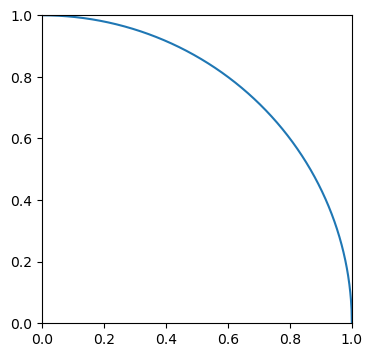

In [4]:
# Plotting just first quadrant, to save computation time.

plt.figure(figsize = (4,4))

plt.plot(x_circle, y_circle)

plt.xlim(0,1)
plt.ylim(0,1)

plt.show()

### 2. Uniformly scatter a given number of points over the square

In [5]:
# Define the number of points to scatter

number_points = 100

In [6]:
# Import random(), which provides numbers between 0 and 1

from random import random, randint

In [7]:
# Example

print(random())

0.3591582126776537


In [8]:
# Function to generate points randomly in the domain

def add_points(rad_circle):
    """
    This function generates points randomly in the domain.
    Inputs: rad_circle
    Outputs: points_x, points_y coordinates(always positive)
    """
    # Since random() generates numbers between 0 and 1, we need to multiply by the radius of the circle to \
    # interpolate the points inside  the domain.
    points_x = random()*rad_circle #we don't want to fix a seed
    points_y = random()*rad_circle

    return points_x, points_y

In [9]:
print(add_points(rad_circle))

(0.6207409100430548, 0.3936890449254806)


In [10]:
## Generate N points in the domain
# Empty lists of coordinates to be filled up
dots_x = []
dots_y = []

for j in range(number_points):

    dots_x.append(add_points(rad_circle)[0])
    dots_y.append(add_points(rad_circle)[1])

print(len(dots_x), len(dots_y))

dots_x = np.array(dots_x)
dots_y = np.array(dots_y)

print(dots_y.shape)

100 100
(100,)


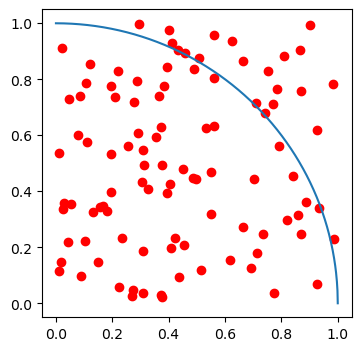

In [11]:
# Plotting

plt.figure(figsize = (4,4))

plt.plot(x_circle, y_circle)
plt.scatter(dots_x, dots_y, color = 'red')

#plt.xlim(0,1)
#plt.ylim(0,1)

plt.show()

### 3. Count the number of points inside the circle


This can be done by having a distance from the origin of less than $r=1$.

In [12]:
# Moduli of the dots

mod_dots = np.sqrt(dots_x**2 + dots_y**2)

#print(mod_dots )

In [13]:
# Double check numbers

print(dots_x[0], dots_y[0], mod_dots[0])

print(dots_x[1], dots_y[1], mod_dots[1])

0.4547983788682438 0.2069284931111064 0.4996608516608199
0.18203987337806682 0.3293466738744897 0.376308048135689


In [14]:
# Conditionals using indexing:

# For dots inside the circle:
dots_inside_x = dots_x[np.where(mod_dots <= rad_circle)]
dots_inside_y = dots_y[np.where(mod_dots <= rad_circle)]


# For dots outside the circle:
dots_outside_x = dots_x[np.where(mod_dots > rad_circle)]
dots_outside_y = dots_y[np.where(mod_dots > rad_circle)]


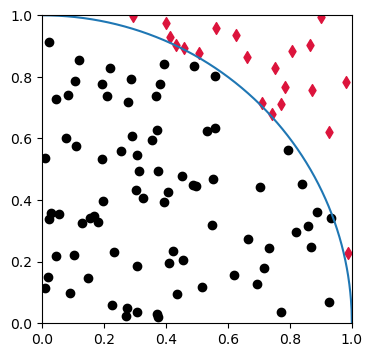

In [15]:
# Plotting using coloured points
plt.figure(figsize = (4,4))
plt.plot(x_circle, y_circle)
plt.scatter(dots_inside_x, dots_inside_y, color = 'black')
plt.scatter(dots_outside_x, dots_outside_y, color = 'crimson', marker = 'd')
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

### 4. The ratio of the inside-count and the total-sample-count is an estimate of the ratio of the two areas. Aggregating the results yields our final result, the approximation of $\pi$.


$\pi =\frac{A_{\rm circle}}{A_{\rm square}}= 4\frac{points_{circle}}{total_{points}}$

The areas are proportional to the number of points.

In [16]:
# Calculate areas inside and outside

area_circle = len(dots_inside_x) #we could use x or y points, since we're just getting the number of points
area_total = len(dots_inside_x) + len(dots_outside_x)

print(area_circle, area_total)

79 100


In [17]:
# Now we print PI:

number_pi = 4*area_circle/area_total

print("Our Monte Carlo simulation indicates that PI is:", number_pi)

Our Monte Carlo simulation indicates that PI is: 3.16


### Show convergence:

Our Monte Carlo simulation indicates that PI is: 4.0
Our Monte Carlo simulation indicates that PI is: 3.0
Our Monte Carlo simulation indicates that PI is: 3.0
Our Monte Carlo simulation indicates that PI is: 3.25
Our Monte Carlo simulation indicates that PI is: 3.0
Our Monte Carlo simulation indicates that PI is: 3.1875
Our Monte Carlo simulation indicates that PI is: 3.4375
Our Monte Carlo simulation indicates that PI is: 3.171875
Our Monte Carlo simulation indicates that PI is: 3.265625
Our Monte Carlo simulation indicates that PI is: 3.0859375
Our Monte Carlo simulation indicates that PI is: 3.125
Our Monte Carlo simulation indicates that PI is: 3.16015625
Our Monte Carlo simulation indicates that PI is: 3.1298828125
Our Monte Carlo simulation indicates that PI is: 3.131591796875
Our Monte Carlo simulation indicates that PI is: 3.1287841796875
Our Monte Carlo simulation indicates that PI is: 3.14544677734375
Our Monte Carlo simulation indicates that PI is: 3.131744384765625
Our Mont

/tmp/ipykernel_10126/2767663371.py:37: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = (4,4))


Our Monte Carlo simulation indicates that PI is: 3.141948699951172
Our Monte Carlo simulation indicates that PI is: 3.1406164169311523
Our Monte Carlo simulation indicates that PI is: 3.1410598754882812
Our Monte Carlo simulation indicates that PI is: 3.1417057514190674


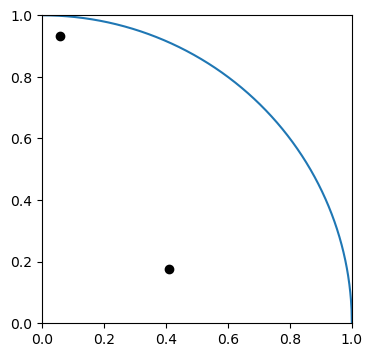

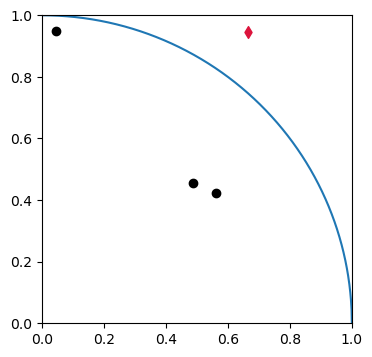

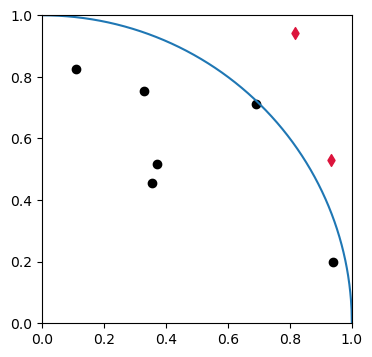

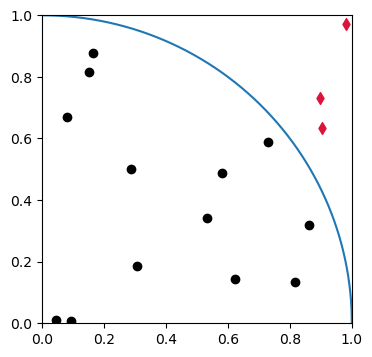

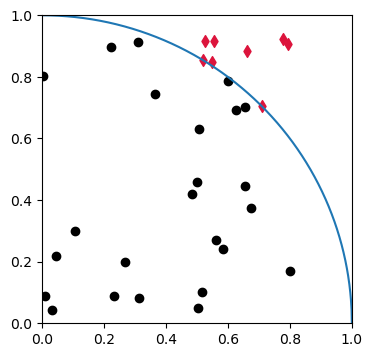

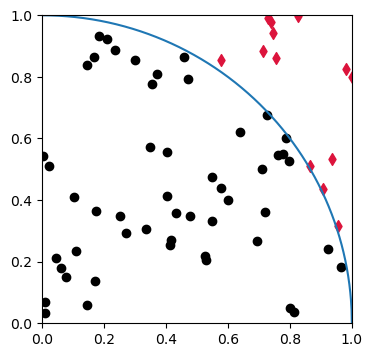

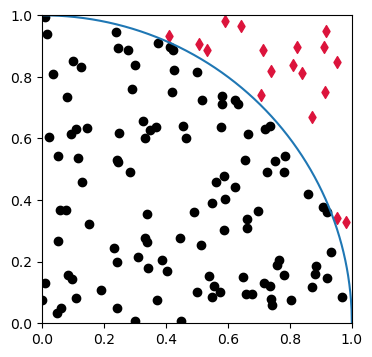

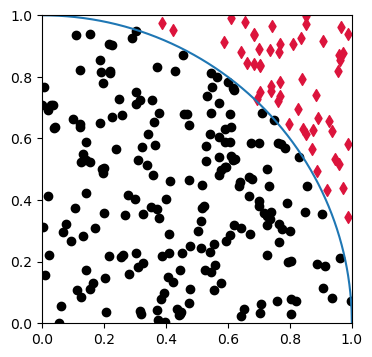

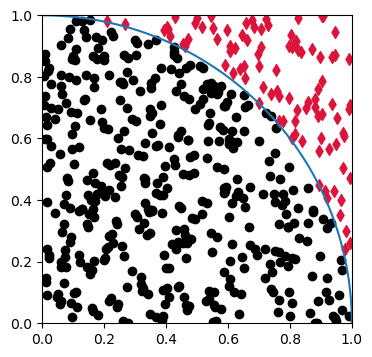

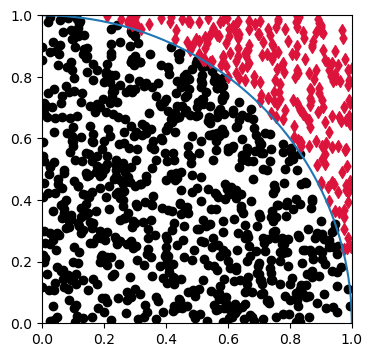

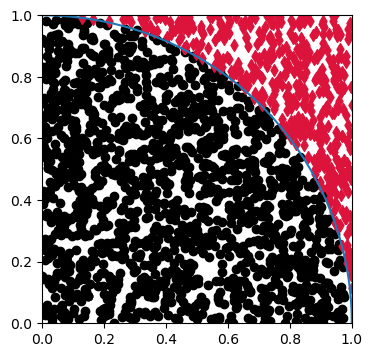

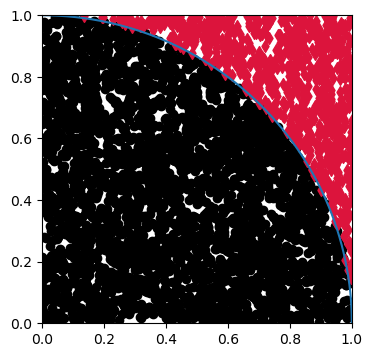

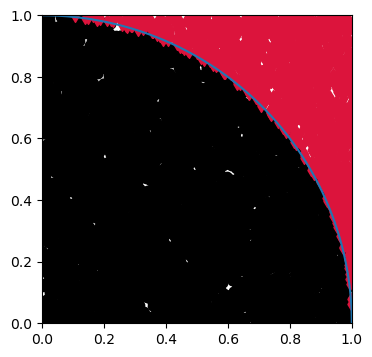

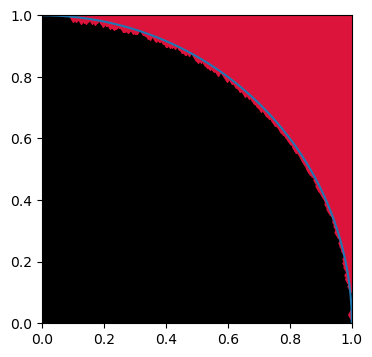

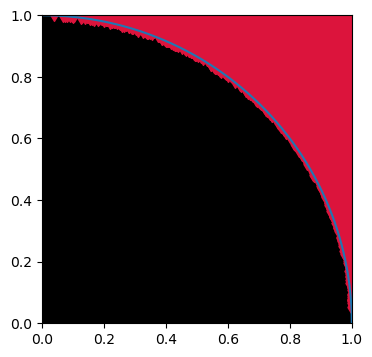

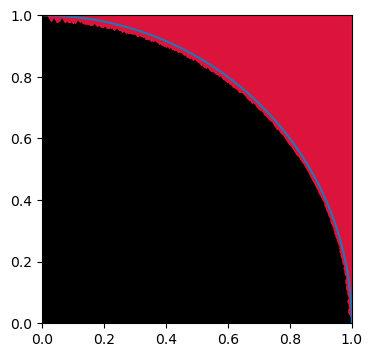

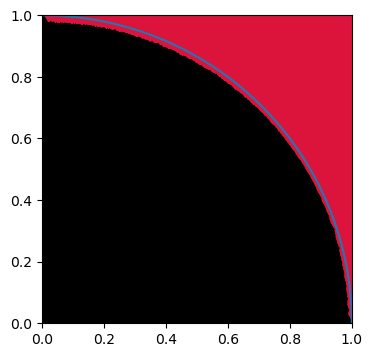

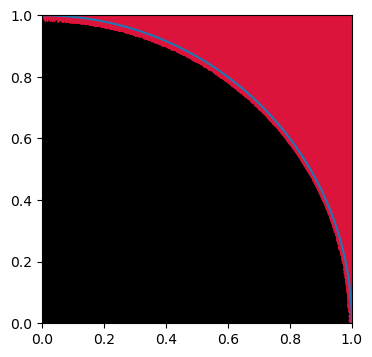

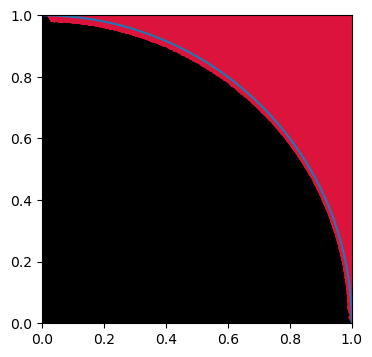

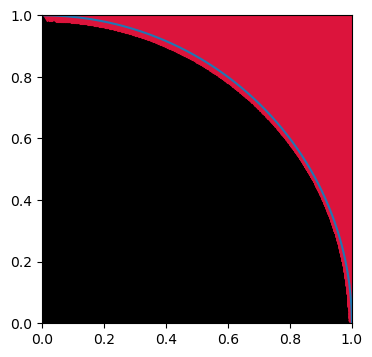

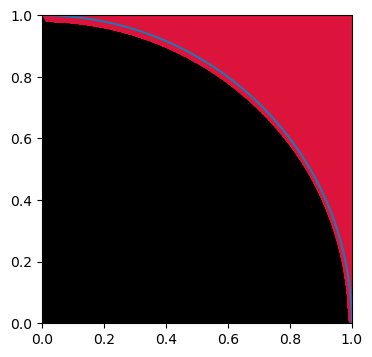

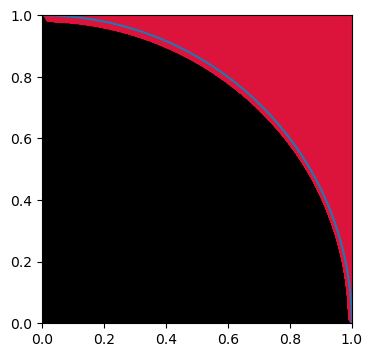

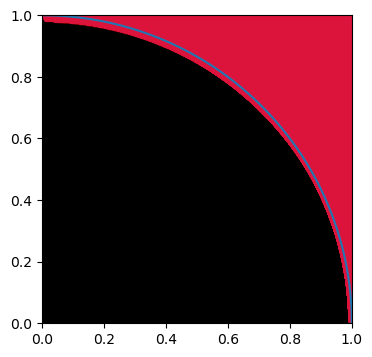

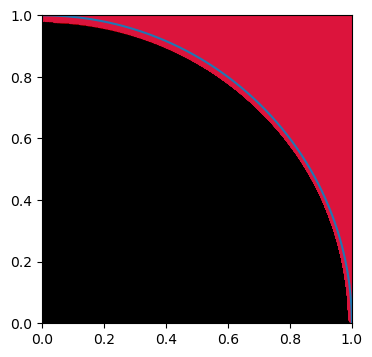

In [18]:
# Iterate for different values of number_points

number_points = 25

pi_numbers = []
kk_numbers = []

for k in range(1, number_points):

    # Empty lists of coord. to filled up
    dots_x = []
    dots_y = []

    for j in range(2**k): #diadic approach
        dots_x.append(add_points(rad_circle)[0])
        dots_y.append(add_points(rad_circle)[1])

    #print(len(dots_x), len(dots_y))

    dots_x = np.array(dots_x)
    dots_y = np.array(dots_y)

    # Moduli of the dots

    mod_dots = np.sqrt(dots_x**2 + dots_y**2)

    # Conditionals:

    # For dots inside the circle:
    dots_inside_x = dots_x[np.where(mod_dots <= rad_circle)]
    dots_inside_y = dots_y[np.where(mod_dots <= rad_circle)]

    # For dots outside the circle:
    dots_outside_x = dots_x[np.where(mod_dots > rad_circle)]
    dots_outside_y = dots_y[np.where(mod_dots > rad_circle)]

    plt.figure(figsize = (4,4))
    plt.plot(x_circle, y_circle)
    plt.scatter(dots_inside_x, dots_inside_y, color = 'black')
    plt.scatter(dots_outside_x, dots_outside_y, color = 'crimson', marker = 'd')
    plt.xlim(0,1)
    plt.ylim(0,1)
    #plt.show()
    plt.savefig("./mc_{:08d}.png".format(j))

    #Areas
    area_circle = len(dots_inside_x)
    area_total = len(dots_inside_x) + len(dots_outside_x)

    #print(area_circle, area_total)

    # Now we print PI:

    number_pi = 4*area_circle/area_total

    print("Our Monte Carlo simulation indicates that PI is:", number_pi)

    pi_numbers.append(number_pi)
    kk_numbers.append(2**k)
# Convert to numpy arrays
pi_numbers = np.array(pi_numbers)

## Convergence plot:

In [19]:
known_pi = np.full(pi_numbers.shape, np.pi)
print(known_pi.shape)

(24,)


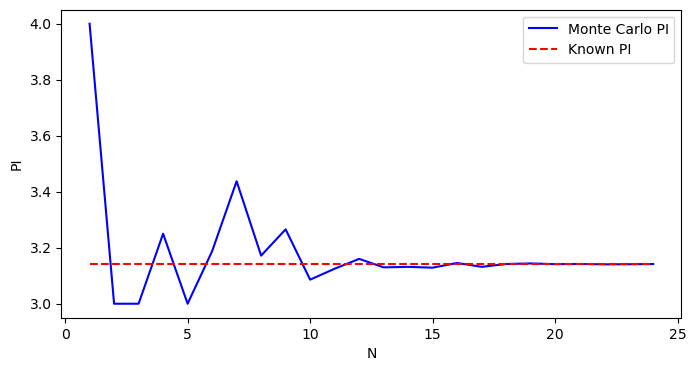

In [20]:
plt.figure(figsize =(8, 4))

plt.plot(np.log2(kk_numbers), pi_numbers, color = 'blue', label = "Monte Carlo PI")

plt.plot(np.log2(kk_numbers), known_pi, color = 'red', linestyle = '--', label = "Known PI")

plt.legend()
plt.xlabel("N")
plt.ylabel("PI")

plt.show()

If we don't know the value to converge to, we could use the criteria of comparing the last and previous value distance by defining a minimum (tolerance). However, the criteria we may use is problem dependent.

### Animation:

In [21]:
from PIL import Image, ImageDraw
import glob 
from IPython import display
import os

In [22]:
def movie_mkr(imgs_input, gif_output):
    """
    This function generates movies (time evolution of images) using glob.
    Inputs: 
        name_input (str, name of the snapshots),\
        name_ouput (str, name of the GIF),\
        t_cgs(array, time_values),\
        rate (array, time values),\
        title (str, title of the plot),\
        filename (str, filename to save plot),\
        output_path_data (directory, output file directory).
    Output: 
        gif
    Author: AlejoS
    Date: 13/05/2025
    """
    imgs = (Image.open(f) for f in sorted(glob.glob(imgs_input)))

    img = next(imgs)

    img.save(fp = gif_output, format="GIF", append_images=imgs,\
        save_all=True, duration = 300, loop = 0)

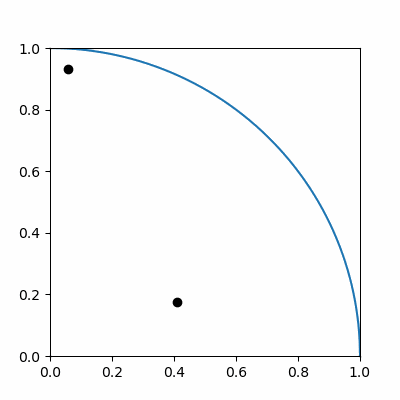

In [23]:
movie_mkr("./mc_********.png", "monte_carlo.gif")

# 3. Display the GIF
display.Image(open("monte_carlo.gif",'rb').read()) #uncomment to show the gif